In [ ]:
import numpy as np
from torchvision.ops import box_iou, nms
from torchvision.utils import draw_bounding_boxes
import matplotlib.pyplot as plt
import torch
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

In [65]:
import torch
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

checkpoint = torch.load("../best.pt", map_location=device)
model = fasterrcnn_resnet50_fpn(weights=None)
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, 5)
model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
model.eval()

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=1e-05)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=1e-05)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=1e-05)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=1e-05)
          (relu

In [66]:
if device.type == "cuda":
    idx = device.index if device.index is not None else torch.cuda.current_device()
    print(torch.cuda.get_device_name(idx))
else:
    print(device.type)

NVIDIA GeForce RTX 3060 Laptop GPU


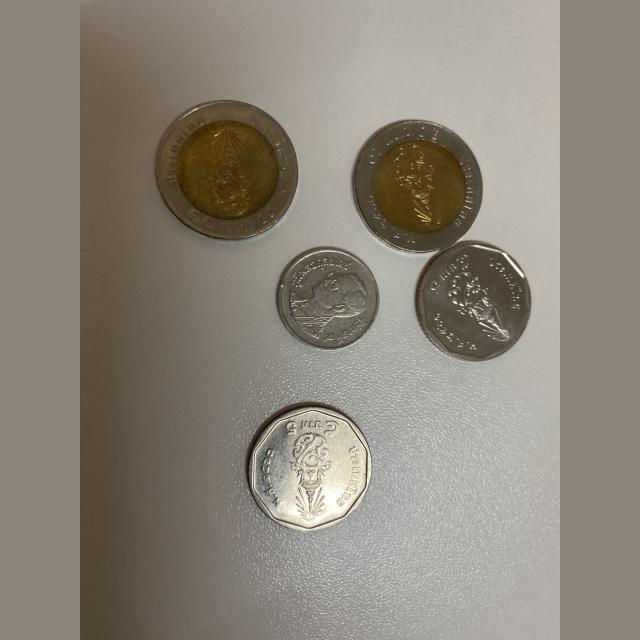

In [67]:
from PIL import Image
img = Image.open("../../datasetCocoTrainTest/test/IMG_2972_JPG.rf.ebcbc9041149e1ce5259135e3b07c791.jpg")
img = img.convert("RGB")
img

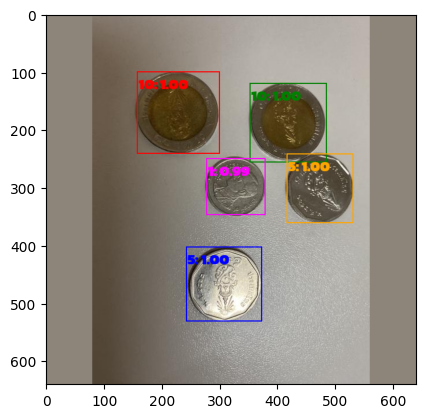

In [ ]:
def filter_nms(pred_boxes, pred_labels, pred_scores, iou_threshold, score_threshold):
    # filter low score boxes
    mask = pred_scores > score_threshold
    pred_boxes = pred_boxes[mask]
    pred_labels = pred_labels[mask]
    pred_scores = pred_scores[mask]

    #  nms to remove overlapping boxes
    mask = nms(pred_boxes, pred_scores, iou_threshold)
    pred_boxes = pred_boxes[mask]
    pred_labels = pred_labels[mask]
    pred_scores = pred_scores[mask]
    return pred_boxes, pred_labels, pred_scores

def draw_bbox_jaaa(img, model, device, classes):
    img = torch.tensor(np.array(img)).permute(2, 0, 1).to(device)
    img_cuda = img.float() / 255.0
    output = model([img_cuda])[0]
    pred_boxes = output["boxes"].cpu()
    pred_labels = output["labels"].cpu().numpy()
    pred_scores = output["scores"].cpu()

    pred_boxes, pred_labels, pred_scores = filter_nms(
        pred_boxes, pred_labels, pred_scores, iou_threshold=0.5, score_threshold=0.5
    )

    # labels with confidence scores
    labels_with_conf = [f"{classes[int(lbl)]}: {float(score):.2f}" for lbl, score in zip(pred_labels, pred_scores)]

    img_int = (img_cuda.cpu() * 255).to(torch.uint8)
    return draw_bounding_boxes(
        img_int, pred_boxes, labels_with_conf, width=2, colors=["blue", "green", "red", "orange", "magenta"], font_size=25, font="../Kanit-Black.ttf"
    ).permute(1, 2, 0)

result = draw_bbox_jaaa(img, model, device, ["__background__", "1", "10", "2", "5"])



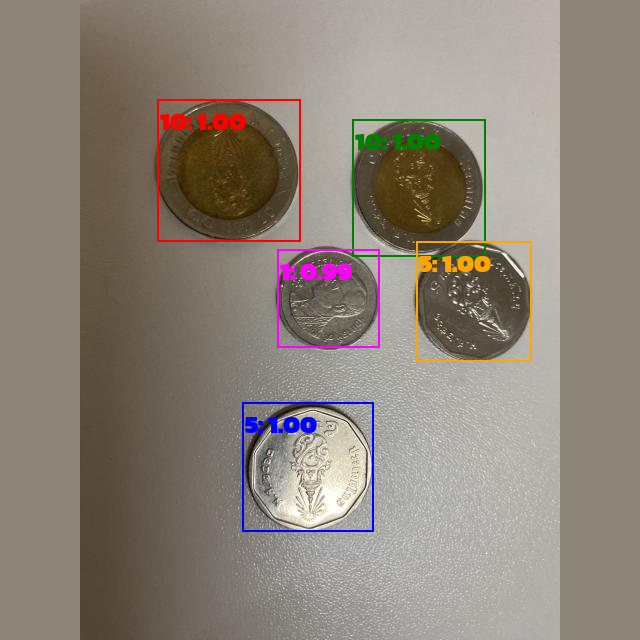

In [90]:
img_out = Image.fromarray(result.cpu().numpy())
img_out

In [92]:
img = Image.open("../../datasetCocoTrainTest/test/IMG_2972_JPG.rf.ebcbc9041149e1ce5259135e3b07c791.jpg")
img = img.convert("RGB")
img = torch.tensor(np.array(img)).permute(2, 0, 1).to(device)
img = img.float() / 255.0
print(img.shape)
preds = model([img])
preds

torch.Size([3, 640, 640])


[{'boxes': tensor([[242.8212, 402.0215, 373.1269, 531.4179],
          [352.0641, 119.6052, 485.2728, 256.3723],
          [157.0807,  99.9650, 300.2524, 241.3597],
          [416.6079, 241.9531, 531.3171, 361.3624],
          [277.8340, 249.9662, 379.1180, 347.4295],
          [417.7241, 244.9759, 532.4377, 362.1146]], device='cuda:0',
         grad_fn=<StackBackward0>),
  'labels': tensor([4, 2, 2, 4, 1, 1], device='cuda:0'),
  'scores': tensor([0.9989, 0.9983, 0.9975, 0.9974, 0.9896, 0.1733], device='cuda:0',
         grad_fn=<IndexBackward0>)}]

In [93]:
preds = preds[0]
pred_boxes = preds["boxes"].cpu()
pred_boxes

tensor([[242.8212, 402.0215, 373.1269, 531.4179],
        [352.0641, 119.6052, 485.2728, 256.3723],
        [157.0807,  99.9650, 300.2524, 241.3597],
        [416.6079, 241.9531, 531.3171, 361.3624],
        [277.8340, 249.9662, 379.1180, 347.4295],
        [417.7241, 244.9759, 532.4377, 362.1146]], grad_fn=<ToCopyBackward0>)

In [95]:
pred_labels = preds["labels"].cpu().numpy()
type(pred_labels)

numpy.ndarray

In [98]:
preds["scores"].backward(retain_graph=True)

RuntimeError: grad can be implicitly created only for scalar outputs